In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("athletes.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  str    
 2   nationality  11538 non-null  str    
 3   sex          11538 non-null  str    
 4   dob          11537 non-null  str    
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  str    
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 991.7 KB


In [3]:
df.drop(['id','name','dob', 'nationality'], axis=1, inplace=True)
df.isna().sum()

sex         0
height    330
weight    659
sport       0
gold        0
silver      0
bronze      0
dtype: int64

In [4]:
df['height'] = df['height'].fillna(df['height'].mean())
df['weight'] = df['weight'].fillna(df['weight'].mean())
df.isna().sum()

sex       0
height    0
weight    0
sport     0
gold      0
silver    0
bronze    0
dtype: int64

In [5]:
df['sex'] = df['sex'].map({'male' : 1, 'female' :0})

In [6]:
df = pd.get_dummies(df, columns=['sport'], drop_first=True)
df.head()

,sex,height,weight,gold,silver,bronze,sport_archery,sport_athletics,sport_badminton,sport_basketball,...,sport_rugby sevens,sport_sailing,sport_shooting,sport_table tennis,sport_taekwondo,sport_tennis,sport_triathlon,sport_volleyball,sport_weightlifting,sport_wrestling
0,1,1.72,64.0,0,0,0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,1.68,56.0,0,0,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,1.98,79.0,0,0,1,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,1.83,80.0,0,0,0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,1,1.81,71.0,0,0,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
X = df.drop('sex', axis=1)
y = df['sex']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

pred = model.predict(X_test_scaled)
prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, prob)
roc_auc = roc_auc_score(y_test, prob)

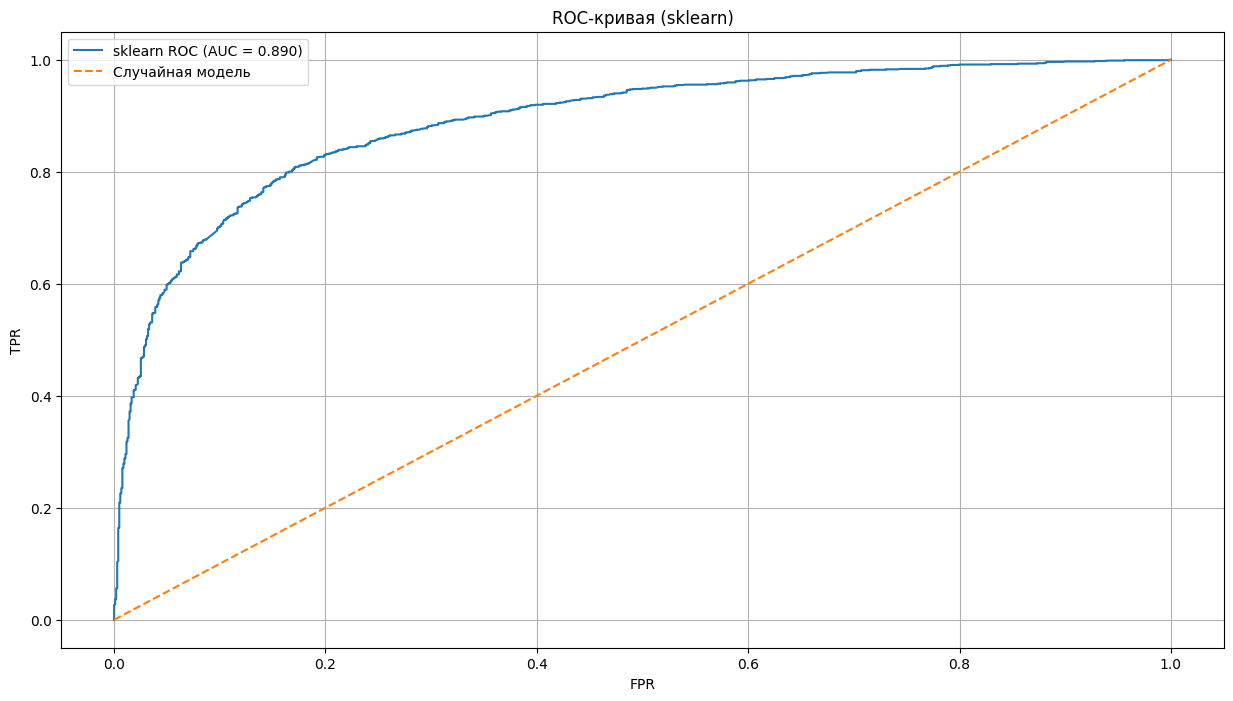

In [9]:
plt.figure(figsize=(15, 8))
plt.plot(fpr, tpr, label=f'sklearn ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], '--', label='Случайная модель')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC-кривая (sklearn)')
plt.legend()
plt.grid()
plt.show()

In [10]:
def compute_tpr_fpr(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    TP = ((y_pred == 1) & (y_true == 1)).sum()
    FP = ((y_pred == 1) & (y_true == 0)).sum()
    TN = ((y_pred == 0) & (y_true == 0)).sum()
    FN = ((y_pred == 0) & (y_true == 1)).sum()
    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)
    return TPR, FPR


def compute_precision_recall(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    TP = ((y_pred == 1) & (y_true == 1)).sum()
    FP = ((y_pred == 1) & (y_true == 0)).sum()
    FN = ((y_pred == 0) & (y_true == 1)).sum()
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    return precision, recall


tpr_manual = []
fpr_manual = []
prec_manual = []
recall_manual = []

for threshold in thresholds:
    tpr, fpr = compute_tpr_fpr(y_test, prob, threshold)
    tpr_manual.append(tpr)
    fpr_manual.append(fpr)

    prec, rec = compute_precision_recall(y_test, prob, threshold)
    prec_manual.append(prec)
    recall_manual.append(rec)

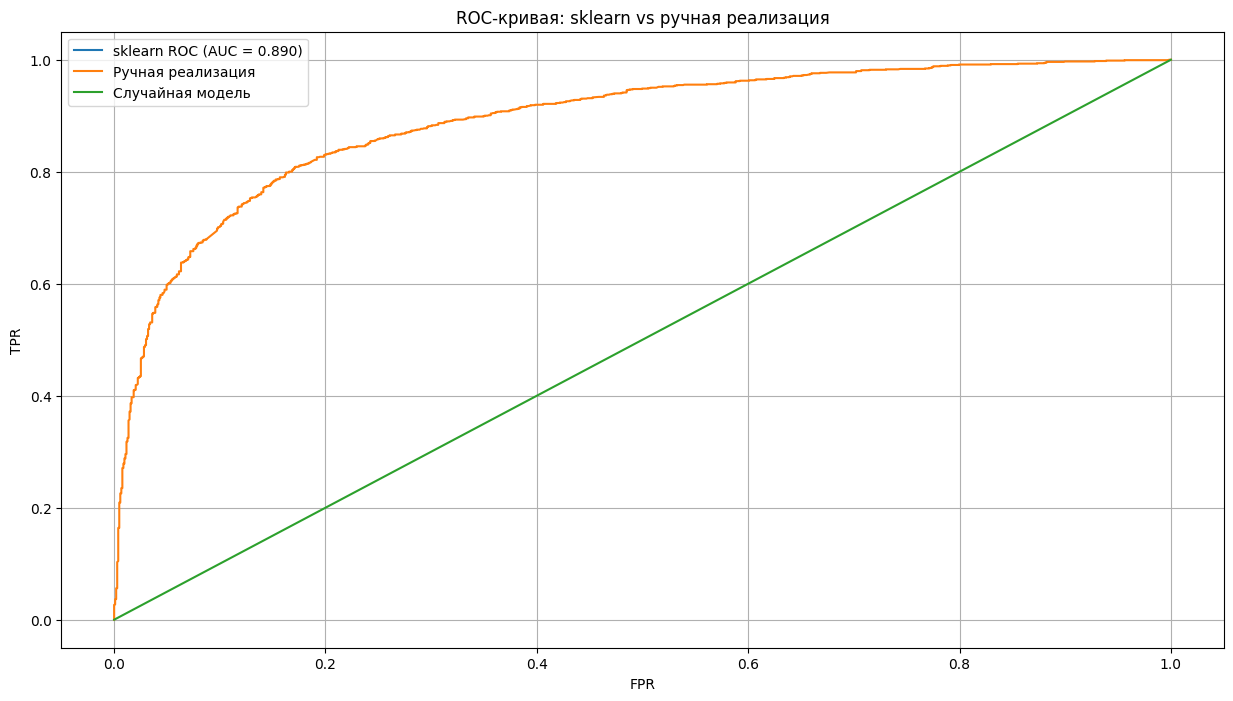

In [11]:
plt.figure(figsize=(15, 8))
plt.plot(fpr, tpr, label=f'sklearn ROC (AUC = {roc_auc:.3f})')
plt.plot(fpr_manual, tpr_manual, label='Ручная реализация')
plt.plot([0, 1], [0, 1], label='Случайная модель',)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC-кривая: sklearn vs ручная реализация')
plt.legend()
plt.grid()
plt.show()

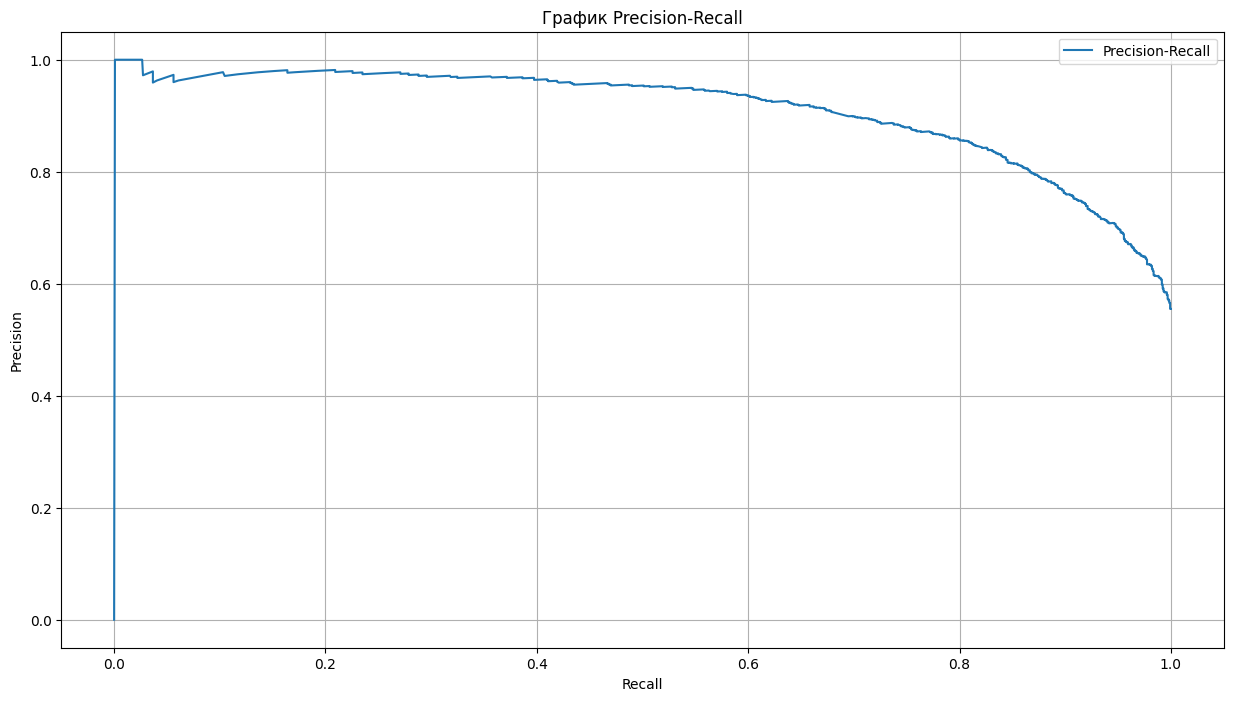

In [12]:
plt.figure(figsize=(15, 8))
plt.plot(recall_manual, prec_manual, label='Precision-Recall')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('График Precision-Recall')
plt.legend()
plt.grid()
plt.show()

**Качество модели**

ROC-кривая находится выше диагонали (AUC > 0.5), что означает что модель лучше случайного угадывания. Чем ближе кривая к верхнему левому углу и чем ближе AUC к 1.0 — тем лучше модель.

Две ROC-кривые (sklearn и ручная реализация) совпадают, что подтверждает правильность ручного расчёта TPR и FPR.


**Оценка модели**

Полученный AUC говорит о хорошем качестве модели при предсказании пола спортсмена.


**Может ли ROC-кривая проходить ниже диагонали?**

Да. Это означает что модель систематически ошибается - предсказывает противоположное правильному ответу. Можно попробовать инвертировать ответы.